# Assignment No. 5 – Generative AI (AI4009)
## Vision Language Model Fine-Tuning with QLoRA for Document-to-Markdown Generation
**Model:** Qwen2-VL-2B-Instruct &nbsp;|&nbsp; **Technique:** QLoRA (4-bit NF4) &nbsp;|&nbsp; **Platform:** Kaggle T4×2


## 1. Environment Setup & Dependency Installation

In [1]:
%%capture
!pip install -q transformers==4.49.0
!pip install -q peft==0.14.0
!pip install -q bitsandbytes==0.45.5
!pip install -q accelerate==1.6.0
!pip install -q trl==0.15.2
!pip install -q qwen-vl-utils
!pip install -q gradio==5.29.0
!pip install -q rouge-score
!pip install -q datasets pillow matplotlib
print("All packages installed successfully!")


## 2. Imports & Global Configuration

In [2]:
import os, gc, re, json, math, random, shutil, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Markdown as MDDisplay

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    Qwen2VLForConditionalGeneration, AutoProcessor,
    BitsAndBytesConfig, get_cosine_schedule_with_warmup,
)
from peft import (
    LoraConfig, get_peft_model, prepare_model_for_kbit_training,
    TaskType, PeftModel,
)
from qwen_vl_utils import process_vision_info

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

# ── Device info ──────────────────────────────────────────────────────────────
print(f"GPUs available : {torch.cuda.device_count()}")
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print(f"  GPU {i}: {p.name}  ({p.total_memory/1e9:.1f} GB)")

# ── Auto-discover dataset path ───────────────────────────────────────────────
kaggle_input = Path("/kaggle/input")
all_dirs = [d for d in kaggle_input.rglob("*") if d.is_dir()]
# Find the 0508 folder (actual data lives there)
target = next((d for d in all_dirs if d.name == "0508"), None)
if target is None:
    # fallback: deepest nougat-related folder
    nougat = [d for d in kaggle_input.iterdir() if d.is_dir() and "nougat" in d.name.lower()]
    target = nougat[0] if nougat else sorted(all_dirs)[-1]
DATASET_DIR = target
print(f"\nDATASET_DIR : {DATASET_DIR}  (exists={DATASET_DIR.exists()})")

# ── Output paths ─────────────────────────────────────────────────────────────
OUTPUT_DIR     = Path("/kaggle/working/outputs")
ADAPTER_DIR    = Path("/kaggle/working/qwen2vl_adapter")
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints")
for d in [OUTPUT_DIR, ADAPTER_DIR, CHECKPOINT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────────────
MODEL_ID       = "Qwen/Qwen2-VL-2B-Instruct"
IMAGE_SIZE     = 256
MAX_SEQ_LEN    = 512
MAX_SAMPLES    = 3000
TRAIN_RATIO    = 0.80
BATCH_SIZE     = 2
GRAD_ACCUM     = 4
LEARNING_RATE  = 2e-4
NUM_EPOCHS     = 3
LORA_RANK      = 16
LORA_ALPHA     = 32
LORA_DROPOUT   = 0.05
WARMUP_RATIO   = 0.10
WEIGHT_DECAY   = 0.01
MAX_NEW_TOKENS = 512
SAVE_EVERY_N   = 1
RESUME         = True

print("\nAll configuration set ✅")


2026-05-08 13:27:58.538881: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778246878.770975      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778246878.834946      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778246879.316213      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778246879.316258      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778246879.316261      57 computation_placer.cc:177] computation placer alr

GPUs available : 2
  GPU 0: Tesla T4  (15.6 GB)
  GPU 1: Tesla T4  (15.6 GB)

DATASET_DIR : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508  (exists=True)

All configuration set ✅


## Part 1: Dataset Exploration

In [3]:
def build_pairs(root: Path):
    """
    Nougat structure:
      0508/
        astro-ph0508001/
          01.png  01.mmd
          02.png  02.mmd   ← multiple pages per paper
    """
    img_exts = {".png", ".jpg", ".jpeg", ".tif", ".tiff"}
    md_exts  = {".mmd", ".md"}
    pairs, skipped = [], 0

    paper_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    print(f"Paper folders : {len(paper_dirs)}")

    for paper_dir in paper_dirs:
        img_map = {f.stem: f for f in paper_dir.iterdir() if f.suffix.lower() in img_exts}
        md_map  = {f.stem: f for f in paper_dir.iterdir() if f.suffix.lower() in md_exts}

        for stem, img_path in img_map.items():
            if stem not in md_map:
                continue
            try:
                with Image.open(img_path) as im:
                    im.verify()          # reject corrupt files
                pairs.append({"image_path": img_path, "md_path": md_map[stem]})
            except Exception:
                skipped += 1

    print(f"Valid pairs   : {len(pairs)}")
    print(f"Skipped (bad) : {skipped}")
    if pairs:
        print(f"Example → {pairs[0]['image_path'].name}  ↔  {pairs[0]['md_path'].name}")
    return pairs

all_pairs = build_pairs(DATASET_DIR)
assert len(all_pairs) > 0, "No pairs found — check DATASET_DIR!"


Paper folders : 2230
Valid pairs   : 14207
Skipped (bad) : 29
Example → 11.png  ↔  11.mmd


In [4]:
# ── Subset & split ───────────────────────────────────────────────────────────
random.shuffle(all_pairs)
pairs      = all_pairs[:MAX_SAMPLES]
split_idx  = int(len(pairs) * TRAIN_RATIO)
train_pairs = pairs[:split_idx]
val_pairs   = pairs[split_idx:]
print(f"Using {len(pairs)} / {len(all_pairs)} total pairs")
print(f"Train : {len(train_pairs)}   Val : {len(val_pairs)}")


Using 3000 / 14207 total pairs
Train : 2400   Val : 600


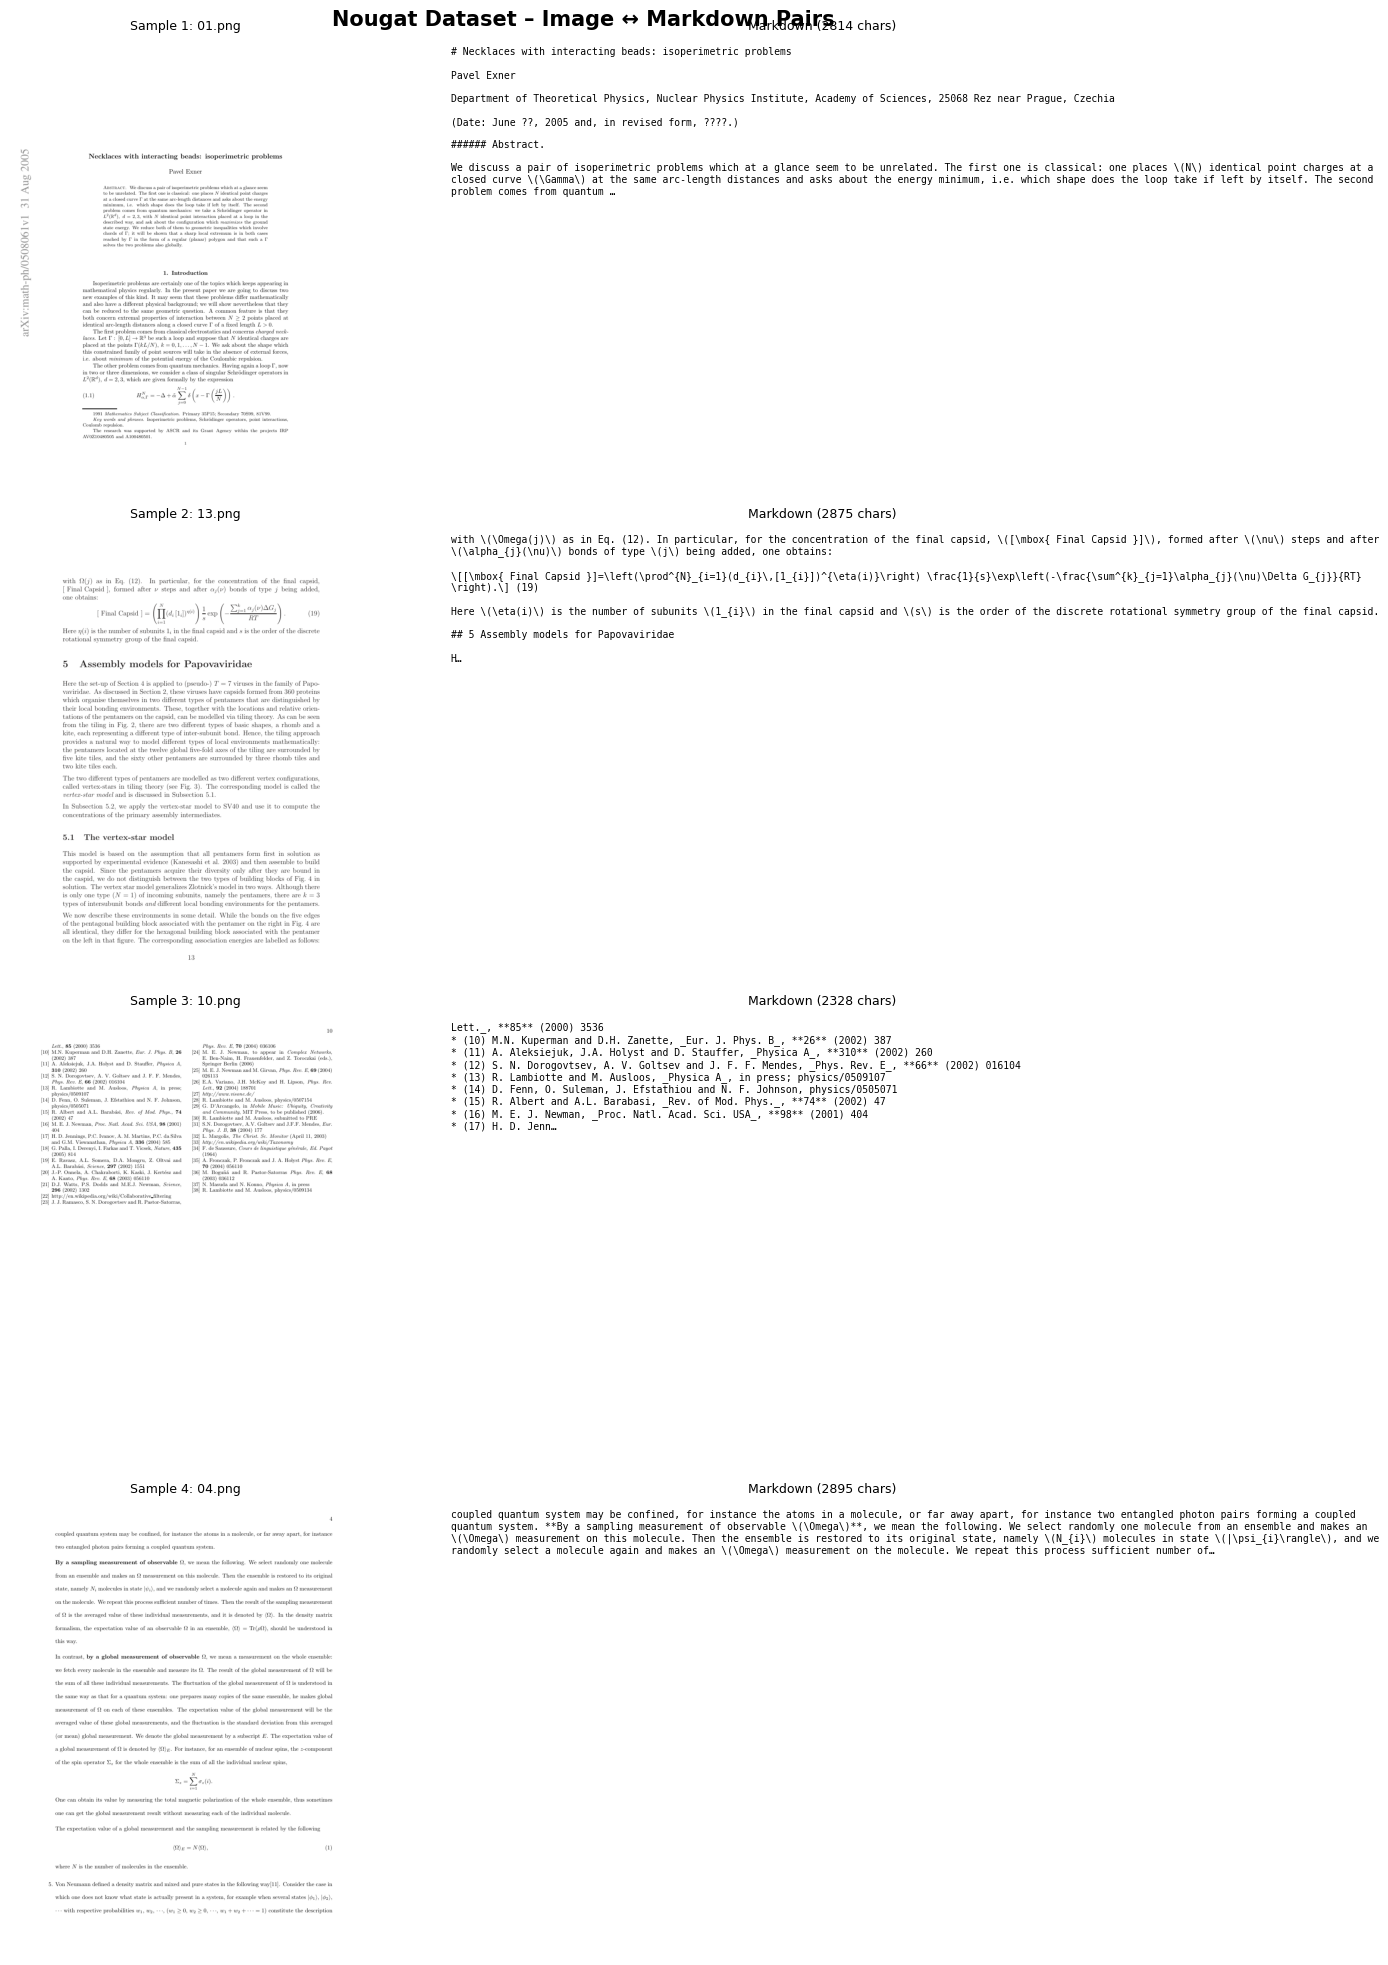

In [5]:
# ── Visual inspection of sample pairs ────────────────────────────────────────
def show_sample_pairs(pairs, n=4):
    fig, axes = plt.subplots(n, 2, figsize=(16, n*5))
    fig.suptitle("Nougat Dataset – Image ↔ Markdown Pairs", fontsize=15, fontweight="bold")
    for i, pair in enumerate(pairs[:n]):
        img = Image.open(pair["image_path"]).convert("RGB")
        txt = pair["md_path"].read_text(encoding="utf-8", errors="replace")
        axes[i,0].imshow(img); axes[i,0].axis("off")
        axes[i,0].set_title(f"Sample {i+1}: {pair['image_path'].name}", fontsize=9)
        axes[i,1].text(0.02, 0.98, txt[:600]+("…" if len(txt)>600 else ""),
                       transform=axes[i,1].transAxes, fontsize=7,
                       verticalalignment="top", family="monospace", wrap=True)
        axes[i,1].set_title(f"Markdown ({len(txt)} chars)", fontsize=9)
        axes[i,1].axis("off")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/"sample_pairs.png", dpi=120, bbox_inches="tight")
    plt.show()

show_sample_pairs(pairs, n=min(4, len(pairs)))


Analysing:   0%|          | 0/3000 [00:00<?, ?it/s]

Markdown → min=59  max=56,807  mean=3,164
Width    → min=794  max=816  mean=816
Height   → min=1056  max=1123  mean=1056


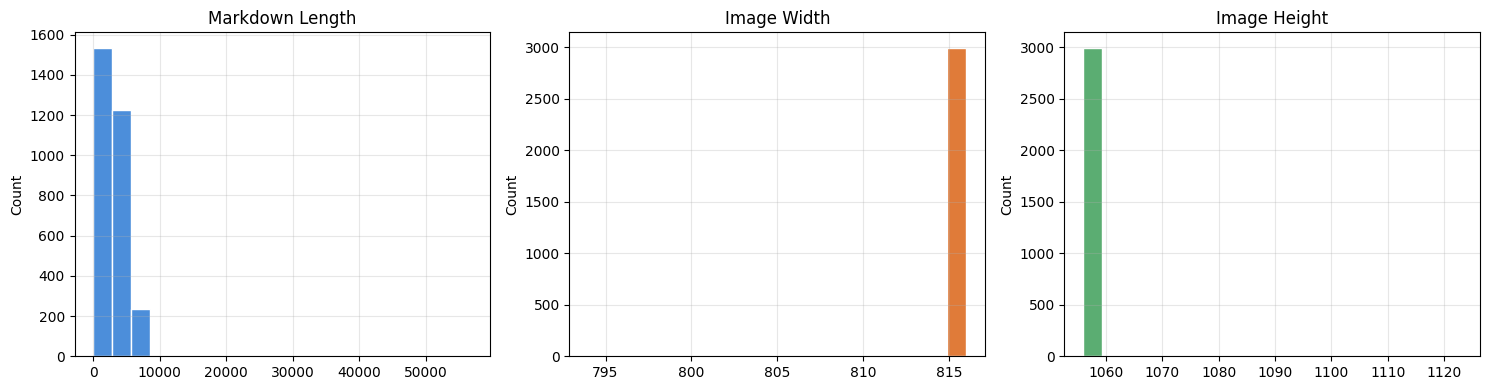

In [6]:
# ── Dataset statistics ────────────────────────────────────────────────────────
md_lengths, img_sizes = [], []
for p in tqdm(pairs, desc="Analysing"):
    try:
        txt = p["md_path"].read_text(encoding="utf-8", errors="replace")
        with Image.open(p["image_path"]) as im:
            im.verify()
        with Image.open(p["image_path"]) as im:
            img_sizes.append(im.size)
        md_lengths.append(len(txt))
    except Exception:
        continue

widths  = [s[0] for s in img_sizes]
heights = [s[1] for s in img_sizes]
print(f"Markdown → min={min(md_lengths):,}  max={max(md_lengths):,}  mean={np.mean(md_lengths):,.0f}")
print(f"Width    → min={min(widths)}  max={max(widths)}  mean={np.mean(widths):.0f}")
print(f"Height   → min={min(heights)}  max={max(heights)}  mean={np.mean(heights):.0f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(md_lengths, bins=20, color="#4C8EDA", edgecolor="white"); axes[0].set_title("Markdown Length")
axes[1].hist(widths,     bins=20, color="#E07B39", edgecolor="white"); axes[1].set_title("Image Width")
axes[2].hist(heights,    bins=20, color="#5BAD72", edgecolor="white"); axes[2].set_title("Image Height")
for ax in axes: ax.set_ylabel("Count"); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"dataset_stats.png", dpi=120, bbox_inches="tight")
plt.show()


## Part 2: Data Preparation – ChatML Format

In [7]:
SYSTEM_PROMPT = (
    "You are an expert document parser. "
    "Convert the provided document image into structured Markdown format. "
    "Preserve all headings, paragraphs, equations, tables, and lists faithfully."
)
INSTRUCTION_PROMPT = (
    "Please convert this document image to Markdown. "
    "Output only the Markdown text, with no additional explanation."
)

def preprocess_image(image_path, size=IMAGE_SIZE):
    img = Image.open(image_path).convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w*scale), int(h*scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    padded = Image.new("RGB", (size, size), (255,255,255))
    padded.paste(img, ((size-nw)//2, (size-nh)//2))
    return padded

def preprocess_image_pil(pil_img, size=IMAGE_SIZE):
    img = pil_img.convert("RGB")
    w, h = img.size
    scale = size / max(w, h)
    nw, nh = int(w*scale), int(h*scale)
    img = img.resize((nw, nh), Image.LANCZOS)
    padded = Image.new("RGB", (size, size), (255,255,255))
    padded.paste(img, ((size-nw)//2, (size-nh)//2))
    return padded

print("Prompts and preprocessing helpers ready ✅")
print(f"System prompt   : {SYSTEM_PROMPT[:80]}…")
print(f"Instruction     : {INSTRUCTION_PROMPT[:80]}…")


Prompts and preprocessing helpers ready ✅
System prompt   : You are an expert document parser. Convert the provided document image into stru…
Instruction     : Please convert this document image to Markdown. Output only the Markdown text, w…


## Part 3: Dataset Splitting (80% Train / 20% Validation)

In [8]:
print(f"Train samples : {len(train_pairs)}")
print(f"Val   samples : {len(val_pairs)}")


Train samples : 2400
Val   samples : 600


## Part 4: QLoRA Fine-Tuning

### 4.1 Load Model & Processor in 4-bit

In [9]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit              = True,
    bnb_4bit_use_double_quant = True,
    bnb_4bit_quant_type       = "nf4",
    bnb_4bit_compute_dtype    = torch.bfloat16,
)

print("Loading processor …")
processor = AutoProcessor.from_pretrained(
    MODEL_ID,
    min_pixels   = 256 * 28 * 28,
    max_pixels   = IMAGE_SIZE * IMAGE_SIZE,
    padding_side = "right",
    use_fast     = True,
)
print(f"Vocab size: {processor.tokenizer.vocab_size:,}")

print("\nLoading Qwen2-VL-2B-Instruct in 4-bit …")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config = bnb_config,
    device_map          = "auto",
    torch_dtype         = torch.bfloat16,
)
model.config.use_cache = False
total = sum(p.numel() for p in model.parameters())
print(f"Total params : {total/1e9:.2f} B")


Loading processor …


preprocessor_config.json:   0%|          | 0.00/347 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

Total params : 1.22 B


### 4.2 Apply LoRA Adapters

In [10]:
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

lora_config = LoraConfig(
    r              = LORA_RANK,
    lora_alpha     = LORA_ALPHA,
    target_modules = ["q_proj","k_proj","v_proj","o_proj",
                       "gate_proj","up_proj","down_proj"],
    lora_dropout   = LORA_DROPOUT,
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()


trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


### 4.3 PyTorch Dataset & DataLoader

In [11]:
class NougatVLMDataset(Dataset):
    def __init__(self, pairs, processor, max_seq_len=MAX_SEQ_LEN):
        self.pairs, self.processor, self.max_seq_len = pairs, processor, max_seq_len

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        pair   = self.pairs[idx]
        img    = preprocess_image(pair["image_path"])
        target = pair["md_path"].read_text(encoding="utf-8", errors="replace").strip()

        msgs_input = [
            {"role":"system",    "content":[{"type":"text","text":SYSTEM_PROMPT}]},
            {"role":"user",      "content":[{"type":"image","image":img},
                                            {"type":"text","text":INSTRUCTION_PROMPT}]},
        ]
        msgs_full = msgs_input + [
            {"role":"assistant","content":[{"type":"text","text":target}]}
        ]

        input_text = self.processor.apply_chat_template(
            msgs_input, tokenize=False, add_generation_prompt=True)
        full_text  = self.processor.apply_chat_template(
            msgs_full,  tokenize=False, add_generation_prompt=False)

        image_inputs, _ = process_vision_info(msgs_full)

        inputs = self.processor(
            text=[full_text], images=image_inputs,
            padding=True, truncation=True,
            max_length=self.max_seq_len, return_tensors="pt",
        )
        input_ids = inputs["input_ids"][0]
        labels    = input_ids.clone()

        prompt_enc = self.processor(
            text=[input_text], images=image_inputs,
            padding=True, truncation=True,
            max_length=self.max_seq_len, return_tensors="pt",
        )
        labels[:prompt_enc["input_ids"].shape[1]] = -100

        return {
            "input_ids"      : input_ids,
            "attention_mask" : inputs["attention_mask"][0],
            "pixel_values"   : inputs.get("pixel_values"),
            "image_grid_thw" : inputs.get("image_grid_thw"),
            "labels"         : labels,
        }

def collate_fn(batch):
    pad_id  = processor.tokenizer.pad_token_id or 0
    max_len = max(b["input_ids"].size(0) for b in batch)
    ids, masks, labs, pv_list, thw_list = [], [], [], [], []
    for b in batch:
        pl = max_len - b["input_ids"].size(0)
        ids.append(  torch.cat([b["input_ids"],       torch.full((pl,), pad_id)]))
        masks.append(torch.cat([b["attention_mask"],  torch.zeros(pl, dtype=torch.long)]))
        labs.append( torch.cat([b["labels"],          torch.full((pl,), -100)]))
        if b["pixel_values"]   is not None: pv_list.append(b["pixel_values"])
        if b["image_grid_thw"] is not None: thw_list.append(b["image_grid_thw"])
    out = {"input_ids":torch.stack(ids),"attention_mask":torch.stack(masks),"labels":torch.stack(labs)}
    if pv_list:  out["pixel_values"]   = torch.cat(pv_list,  dim=0)
    if thw_list: out["image_grid_thw"] = torch.cat(thw_list, dim=0)
    return out

train_dataset = NougatVLMDataset(train_pairs, processor)
val_dataset   = NougatVLMDataset(val_pairs,   processor)
train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                            collate_fn=collate_fn, num_workers=0, pin_memory=False)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                            collate_fn=collate_fn, num_workers=0, pin_memory=False)
print(f"Train batches : {len(train_loader)}   Val batches : {len(val_loader)}")


Train batches : 1200   Val batches : 300


### 4.4 Optimizer, Scheduler & Checkpoint Helpers

In [12]:
from torch.optim import AdamW

optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY, betas=(0.9, 0.999),
)
total_steps  = (len(train_loader) // GRAD_ACCUM) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)
print(f"Optimizer steps  : {total_steps}   Warmup : {warmup_steps}")

# ── Checkpoint helpers ───────────────────────────────────────────────────────
def save_checkpoint(epoch, tr_loss, val_loss, is_best=False):
    ckpt = CHECKPOINT_DIR / f"epoch_{epoch:02d}"
    ckpt.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(ckpt)
    processor.save_pretrained(ckpt)
    torch.save({
        "epoch": epoch, "train_losses": train_losses, "val_losses": val_losses,
        "best_val_loss": best_val_loss,
        "optimizer": optimizer.state_dict(), "scheduler": scheduler.state_dict(),
    }, ckpt / "trainer_state.pt")
    print(f"  💾 Checkpoint → {ckpt.name}")
    if is_best:
        if ADAPTER_DIR.exists(): shutil.rmtree(ADAPTER_DIR)
        shutil.copytree(ckpt, ADAPTER_DIR)
        print(f"  ✅ Best model  → {ADAPTER_DIR}")

def load_latest_checkpoint():
    ckpts = sorted(CHECKPOINT_DIR.glob("epoch_*"))
    if not ckpts:
        print("  No checkpoint — starting fresh.")
        return 1, [], [], float("inf")
    latest = ckpts[-1]
    state  = torch.load(latest/"trainer_state.pt", map_location="cpu")
    try:
        from peft import set_peft_model_state_dict
        from safetensors.torch import load_file as safe_load
        w = safe_load(str(latest/"adapter_model.safetensors"), device="cpu")
        set_peft_model_state_dict(model, w)
        print(f"  🔄 Adapter weights restored from {latest.name}")
    except Exception as e:
        print(f"  ⚠️  Could not restore adapter: {e}")
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    print(f"  ▶️  Resuming from epoch {state['epoch']+1}  (best val={state['best_val_loss']:.4f})")
    return state["epoch"]+1, state["train_losses"], state["val_losses"], state["best_val_loss"]


Optimizer steps  : 900   Warmup : 90


### 4.5 Training Loop

In [13]:
train_losses, val_losses, best_val_loss, start_epoch = [], [], float("inf"), 1
if RESUME:
    start_epoch, train_losses, val_losses, best_val_loss = load_latest_checkpoint()

def run_epoch(loader, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, steps = 0.0, 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for step, batch in enumerate(tqdm(loader, desc="Train" if is_train else "Val ", leave=False)):
            batch = {k: v.to("cuda:0") if isinstance(v, torch.Tensor) else v for k,v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"], attention_mask=batch["attention_mask"],
                pixel_values=batch.get("pixel_values"), image_grid_thw=batch.get("image_grid_thw"),
                labels=batch["labels"],
            )
            loss = outputs.loss / GRAD_ACCUM
            if is_train:
                loss.backward()
                if (step+1) % GRAD_ACCUM == 0:
                    torch.nn.utils.clip_grad_norm_(
                        filter(lambda p: p.requires_grad, model.parameters()), 1.0)
                    optimizer.step(); scheduler.step(); optimizer.zero_grad()
            total_loss += loss.item() * GRAD_ACCUM
            steps += 1
    return total_loss / max(steps, 1)

for epoch in range(start_epoch, NUM_EPOCHS+1):
    print(f"\n{'='*60}\n  EPOCH {epoch}/{NUM_EPOCHS}\n{'='*60}")
    tr_loss  = run_epoch(train_loader, is_train=True)
    val_loss = run_epoch(val_loader,   is_train=False)
    train_losses.append(tr_loss); val_losses.append(val_loss)
    print(f"  Train loss : {tr_loss:.4f}")
    print(f"  Val   loss : {val_loss:.4f}")
    is_best = val_loss < best_val_loss
    if is_best: best_val_loss = val_loss
    if epoch % SAVE_EVERY_N == 0 or is_best:
        save_checkpoint(epoch, tr_loss, val_loss, is_best=is_best)
    gc.collect(); torch.cuda.empty_cache()

print(f"\nTraining complete!  Best val loss: {best_val_loss:.4f}")


  No checkpoint — starting fresh.

  EPOCH 1/3


Train:   0%|          | 0/1200 [00:00<?, ?it/s]

Val :   0%|          | 0/300 [00:00<?, ?it/s]

  Train loss : 1.8813
  Val   loss : 1.8353
  💾 Checkpoint → epoch_01
  ✅ Best model  → /kaggle/working/qwen2vl_adapter

  EPOCH 2/3


Train:   0%|          | 0/1200 [00:00<?, ?it/s]

Val :   0%|          | 0/300 [00:00<?, ?it/s]

  Train loss : 1.6135
  Val   loss : 1.8267
  💾 Checkpoint → epoch_02
  ✅ Best model  → /kaggle/working/qwen2vl_adapter

  EPOCH 3/3


Train:   0%|          | 0/1200 [00:00<?, ?it/s]

Val :   0%|          | 0/300 [00:00<?, ?it/s]

  Train loss : 1.3462
  Val   loss : 1.8966
  💾 Checkpoint → epoch_03

Training complete!  Best val loss: 1.8267


### 4.6 Loss Curves

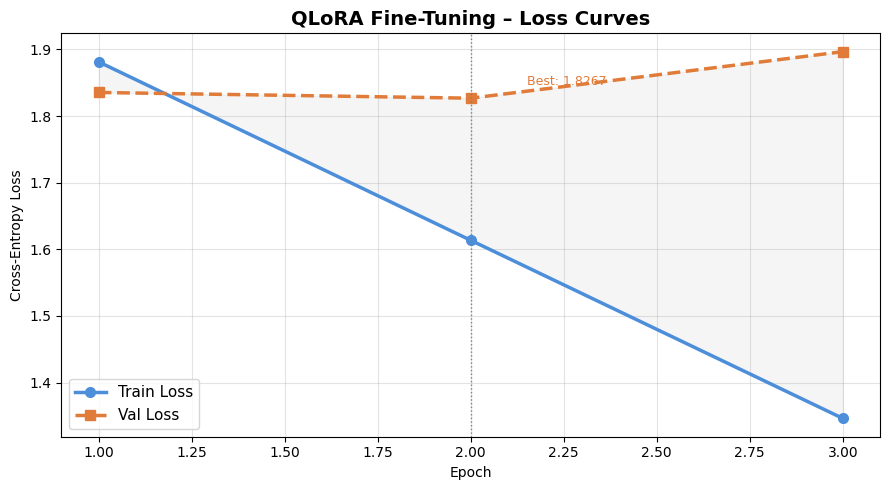

In [14]:
epochs = list(range(1, len(train_losses)+1))
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(epochs, train_losses, "o-",  color="#4C8EDA", lw=2.5, ms=7, label="Train Loss")
ax.plot(epochs, val_losses,   "s--", color="#E07B39", lw=2.5, ms=7, label="Val Loss")
ax.fill_between(epochs, train_losses, val_losses, alpha=0.08, color="grey")
if val_losses:
    best_ep = val_losses.index(min(val_losses))+1
    ax.axvline(best_ep, color="grey", lw=1, ls=":")
    ax.annotate(f"Best: {min(val_losses):.4f}", xy=(best_ep, min(val_losses)),
                xytext=(best_ep+0.15, min(val_losses)+0.02), fontsize=9, color="#E07B39")
ax.set_title("QLoRA Fine-Tuning – Loss Curves", fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(fontsize=11); ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"loss_curves.png", dpi=130, bbox_inches="tight")
plt.show()


## Part 5: Markdown Generation on Validation Set

In [15]:
print("Loading best adapter for inference …")
inference_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config,
    device_map="auto", torch_dtype=torch.bfloat16,
)
inference_model = PeftModel.from_pretrained(inference_model, ADAPTER_DIR)
inference_model.eval()
print("Best adapter loaded ✅")

def generate_markdown(image, mdl, proc, max_new_tokens=MAX_NEW_TOKENS):
    if isinstance(image, (str, Path)):
        image = preprocess_image(image)
    msgs = [
        {"role":"system","content":[{"type":"text","text":SYSTEM_PROMPT}]},
        {"role":"user",  "content":[{"type":"image","image":image},
                                    {"type":"text","text":INSTRUCTION_PROMPT}]},
    ]
    text = proc.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    img_inputs, _ = process_vision_info(msgs)
    inputs = proc(text=[text], images=img_inputs, return_tensors="pt").to("cuda:0")
    with torch.no_grad():
        out = mdl.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False,
            repetition_penalty=1.1,
            eos_token_id=proc.tokenizer.eos_token_id,
            pad_token_id=proc.tokenizer.eos_token_id,
        )
    generated = out[0][inputs["input_ids"].shape[1]:]
    return proc.tokenizer.decode(generated, skip_special_tokens=True).strip()


Loading best adapter for inference …


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Best adapter loaded ✅


In [16]:
from rouge_score import rouge_scorer as rs_module
scorer = rs_module.RougeScorer(["rouge1","rougeL"], use_stemmer=True)

val_results = []
for pair in tqdm(val_pairs[:10], desc="Generating Markdown"):
    img  = preprocess_image(pair["image_path"])
    gt   = pair["md_path"].read_text(encoding="utf-8", errors="replace").strip()
    pred = generate_markdown(img, inference_model, processor)
    sc   = scorer.score(gt, pred)
    val_results.append({
        "image_path": pair["image_path"], "ground_truth": gt, "predicted": pred,
        "rouge1": sc["rouge1"].fmeasure, "rougeL": sc["rougeL"].fmeasure,
    })

df_val = pd.DataFrame(val_results)
print("\n── Validation ROUGE Scores ──")
print(df_val[["rouge1","rougeL"]].describe().round(4))


Generating Markdown:   0%|          | 0/10 [00:00<?, ?it/s]


── Validation ROUGE Scores ──
        rouge1   rougeL
count  10.0000  10.0000
mean    0.3475   0.2266
std     0.1593   0.1150
min     0.0071   0.0053
25%     0.2881   0.1608
50%     0.3905   0.2357
75%     0.4325   0.2964
max     0.5471   0.4126


## 5. Visualization – Ground Truth vs Predicted Markdown

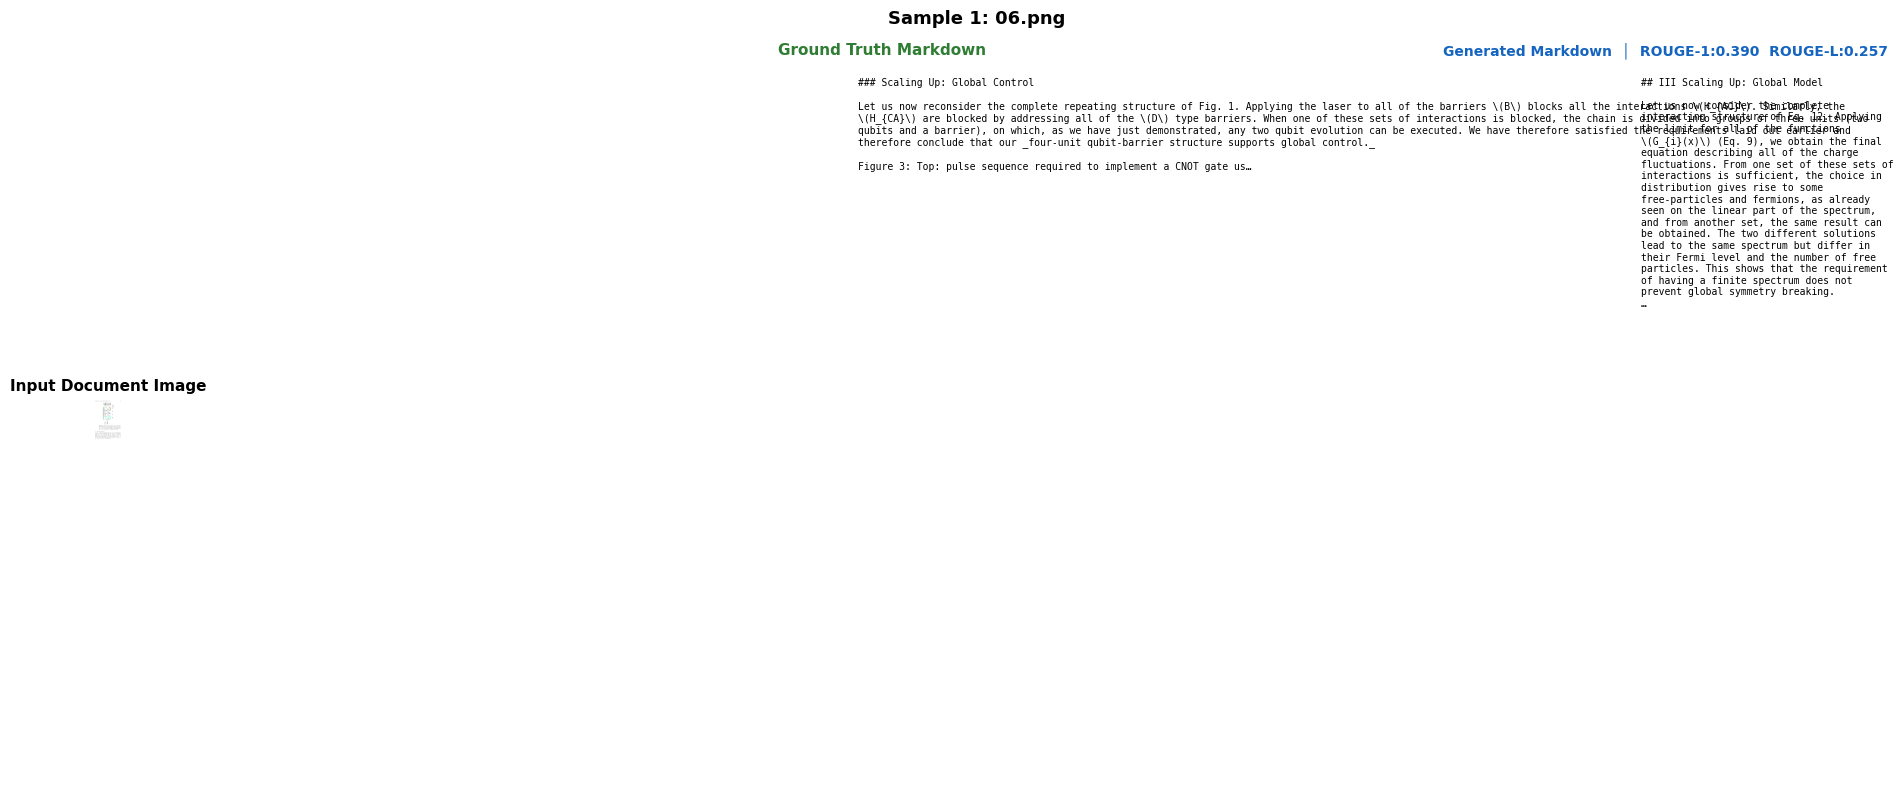

  Saved → /kaggle/working/outputs/val_result_1.png


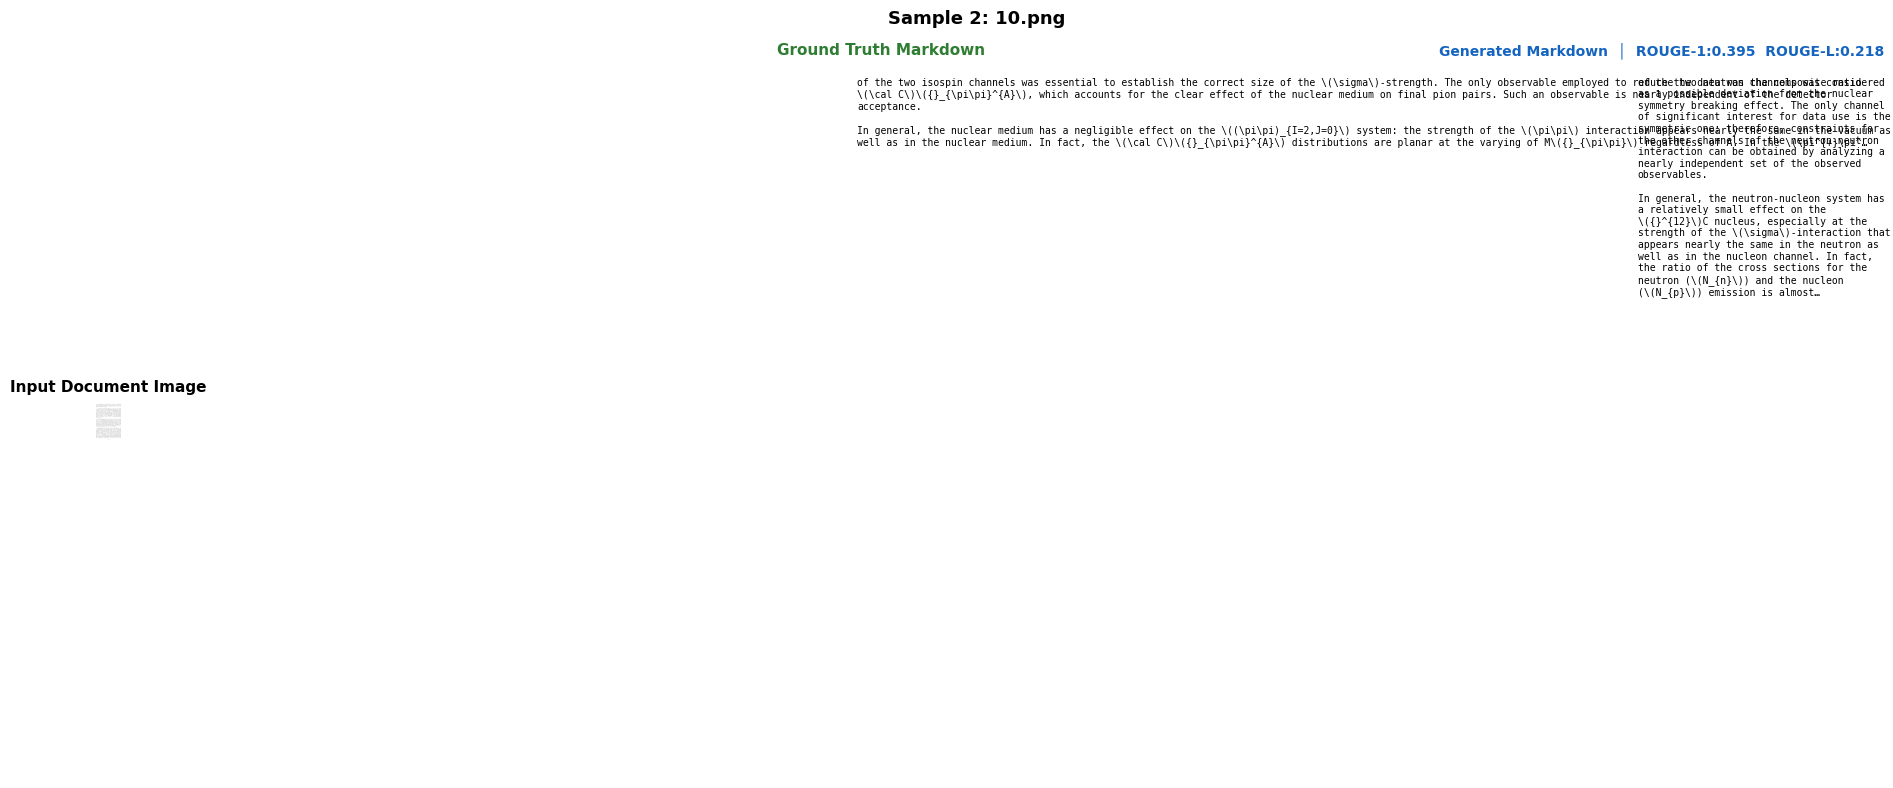

  Saved → /kaggle/working/outputs/val_result_2.png


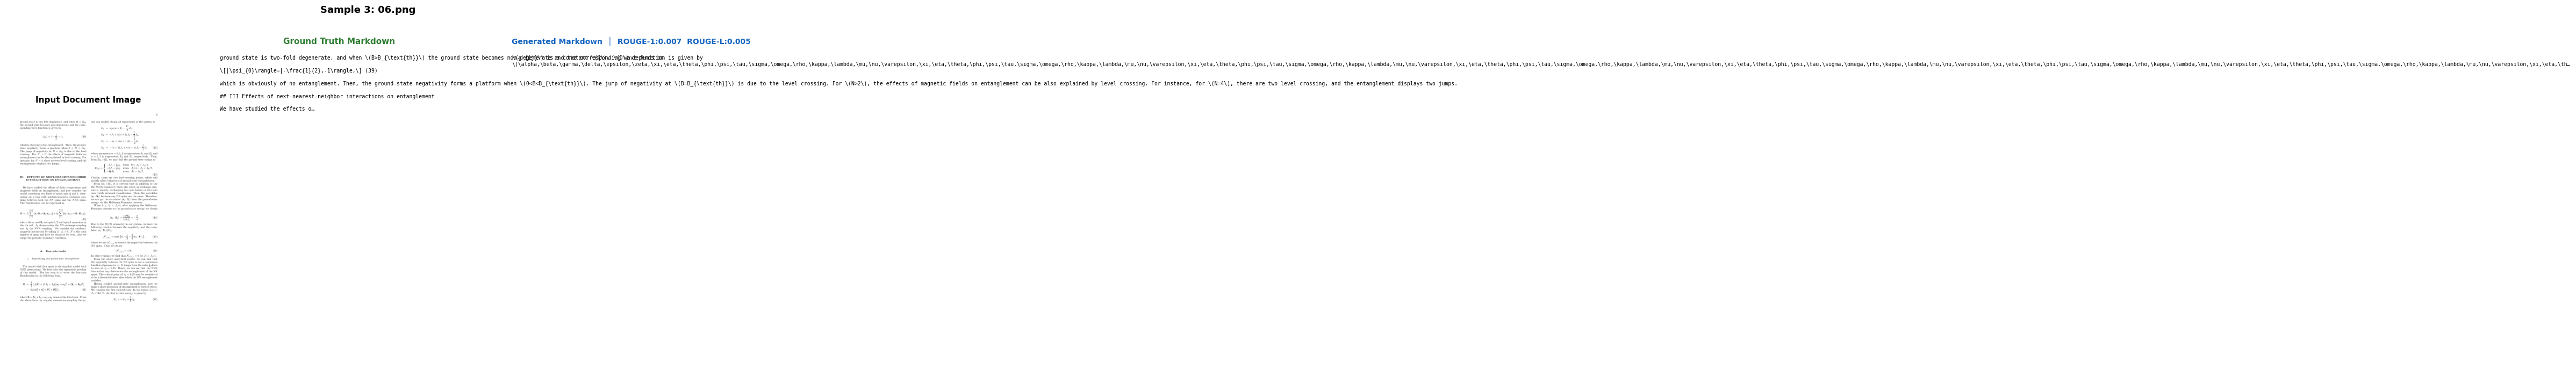

  Saved → /kaggle/working/outputs/val_result_3.png


In [17]:
def visualise_predictions(results, n=3, save_prefix="val"):
    for i, r in enumerate(results[:n]):
        fig = plt.figure(figsize=(18, 8))
        gs  = gridspec.GridSpec(1, 3, figure=fig, width_ratios=[1,1.5,1.5])
        # Image
        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(Image.open(r["image_path"]).convert("RGB"))
        ax0.set_title("Input Document Image", fontsize=11, fontweight="bold"); ax0.axis("off")
        # Ground truth
        ax1 = fig.add_subplot(gs[1])
        ax1.text(0.02,0.98, r["ground_truth"][:700]+("…" if len(r["ground_truth"])>700 else ""),
                 transform=ax1.transAxes, fontsize=7, va="top", family="monospace", wrap=True)
        ax1.set_title("Ground Truth Markdown", fontsize=11, fontweight="bold", color="#2e7d32")
        ax1.axis("off"); ax1.set_facecolor("#f1f8e9")
        # Predicted
        ax2 = fig.add_subplot(gs[2])
        ax2.text(0.02,0.98, r["predicted"][:700]+("…" if len(r["predicted"])>700 else ""),
                 transform=ax2.transAxes, fontsize=7, va="top", family="monospace", wrap=True)
        ax2.set_title(
            f"Generated Markdown  │  ROUGE-1:{r.get('rouge1',0):.3f}  ROUGE-L:{r.get('rougeL',0):.3f}",
            fontsize=10, fontweight="bold", color="#1565c0")
        ax2.axis("off"); ax2.set_facecolor("#e3f2fd")
        fig.suptitle(f"Sample {i+1}: {Path(r['image_path']).name}", fontsize=13, fontweight="bold")
        plt.tight_layout()
        fname = OUTPUT_DIR/f"{save_prefix}_result_{i+1}.png"
        plt.savefig(fname, dpi=120, bbox_inches="tight"); plt.show()
        print(f"  Saved → {fname}")

visualise_predictions(val_results, n=min(3, len(val_results)))


## Part 6: Testing Task

### 6.1 – 3 Training Images

Train-set testing:   0%|          | 0/3 [00:00<?, ?it/s]

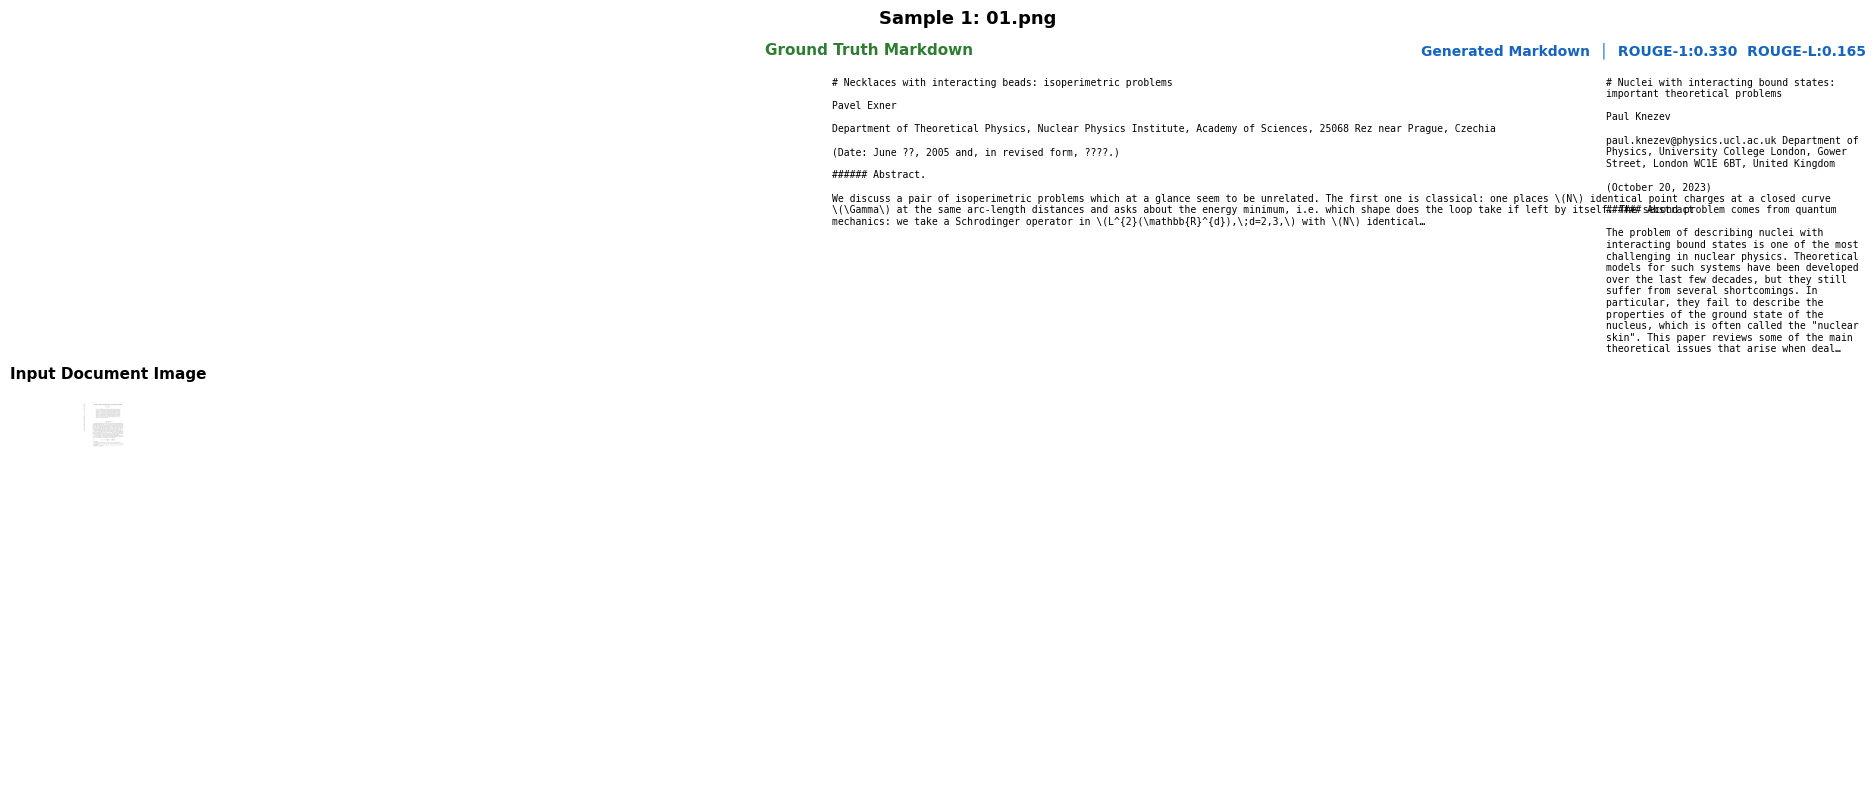

  Saved → /kaggle/working/outputs/train_test_result_1.png


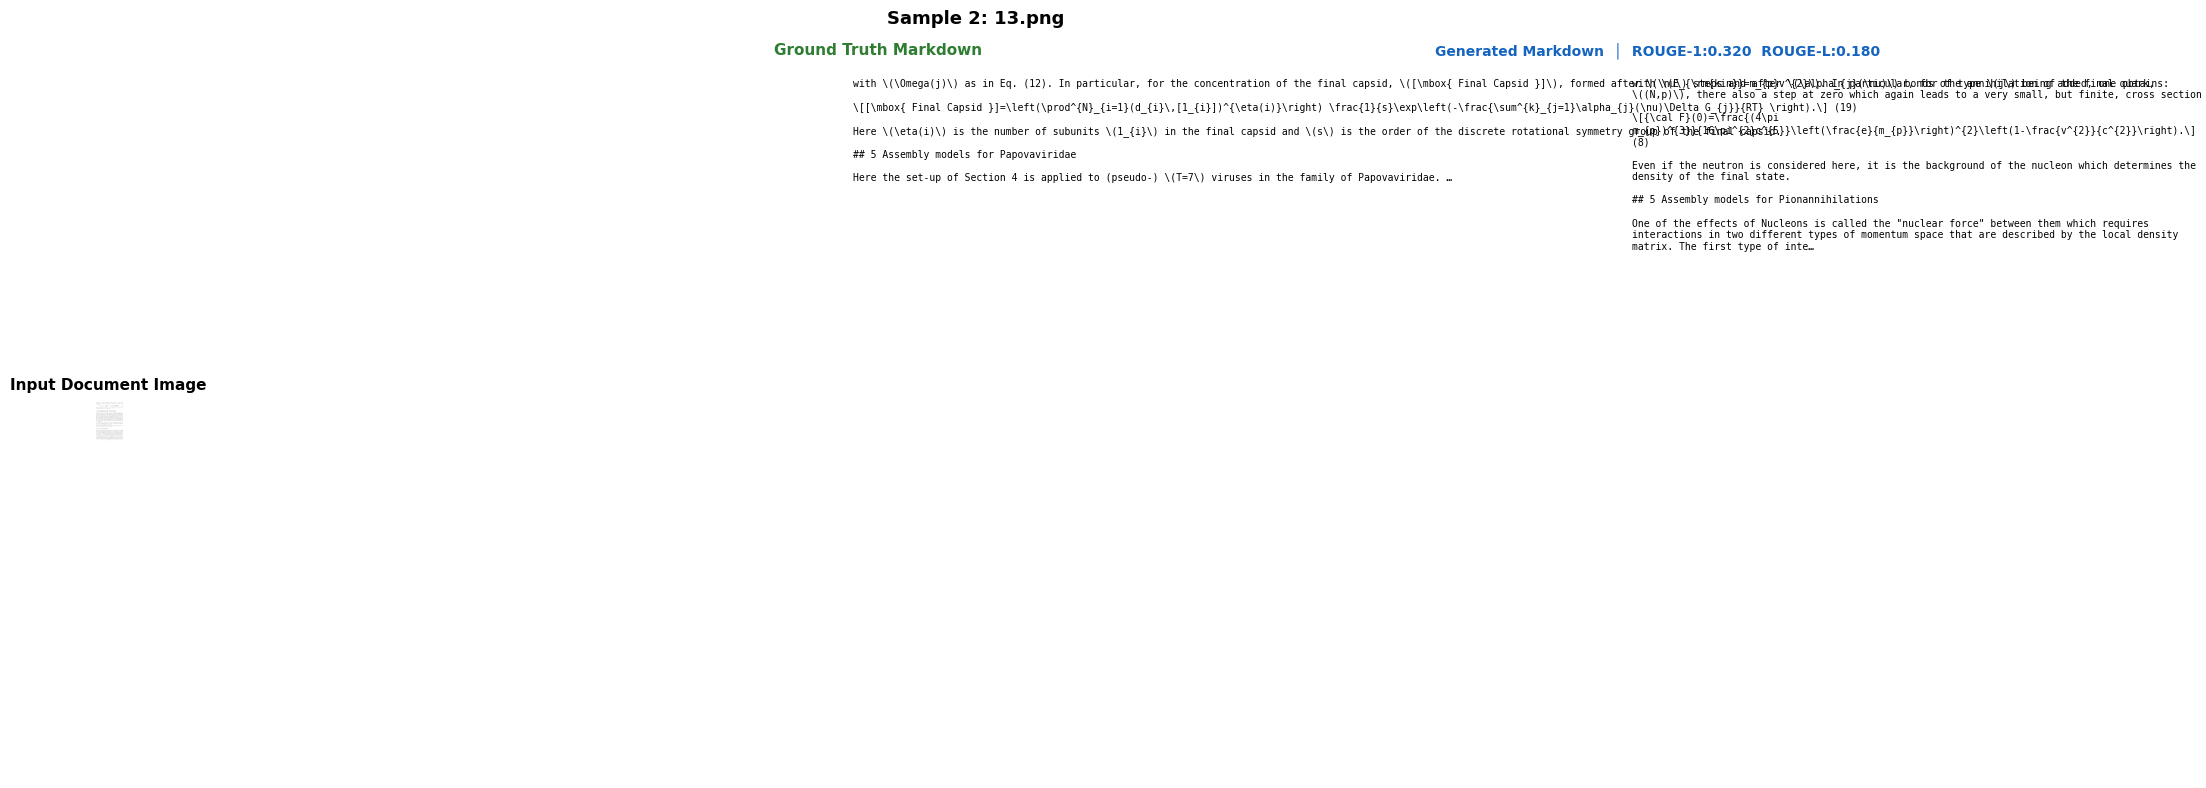

  Saved → /kaggle/working/outputs/train_test_result_2.png


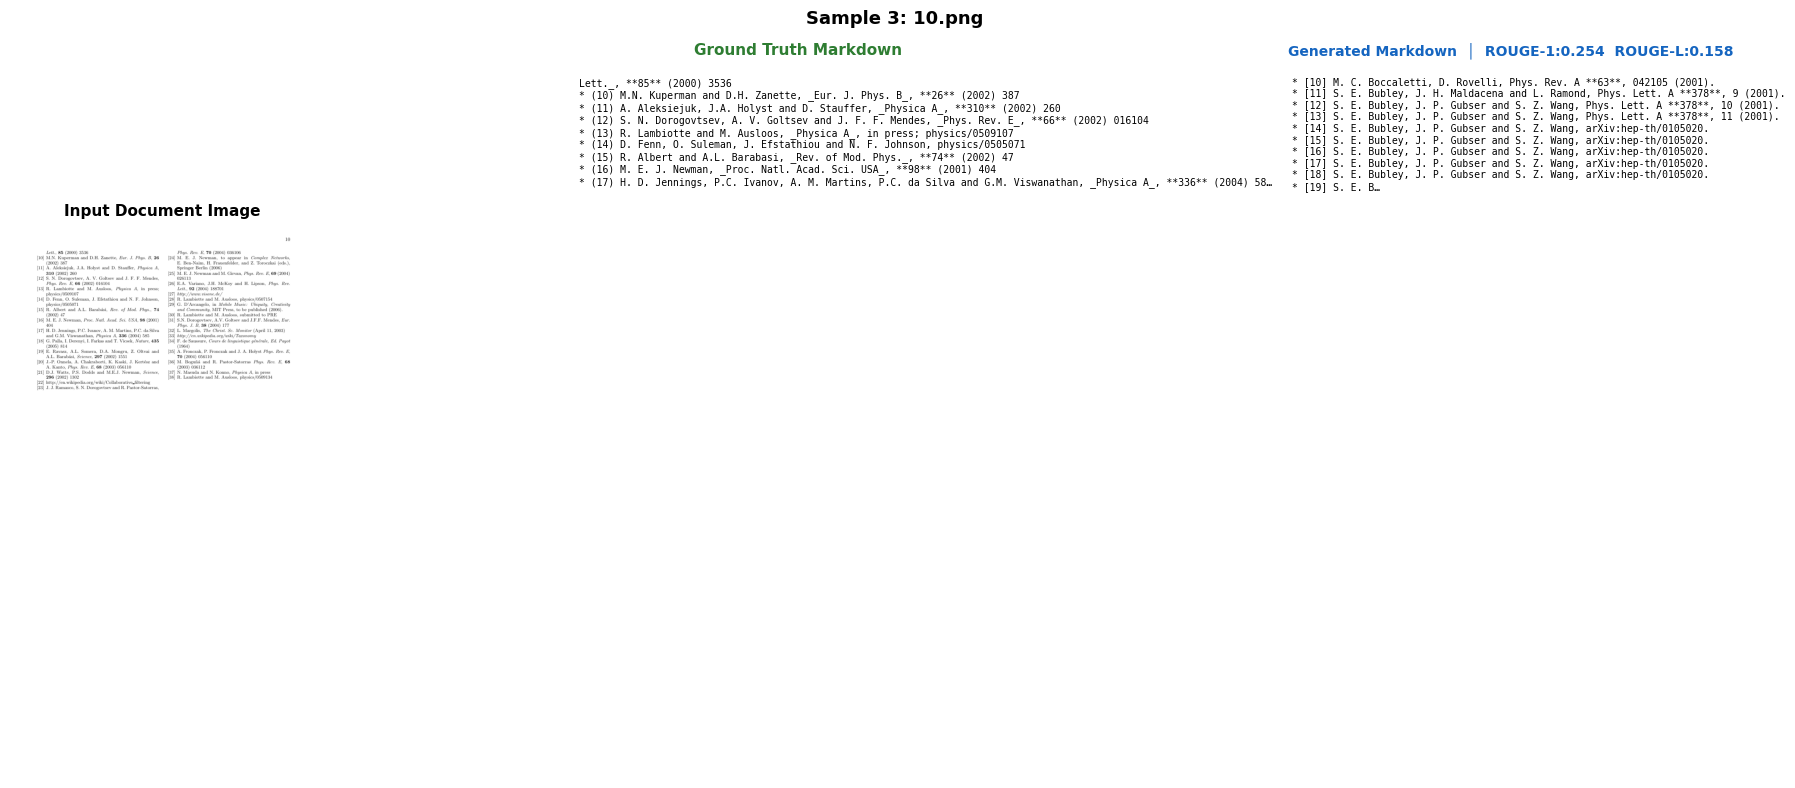

  Saved → /kaggle/working/outputs/train_test_result_3.png

── Train-set ROUGE Scores ──
  01.png: ROUGE-1=0.330  ROUGE-L=0.165
  13.png: ROUGE-1=0.320  ROUGE-L=0.180
  10.png: ROUGE-1=0.254  ROUGE-L=0.158


In [18]:
train_test_results = []
for pair in tqdm(train_pairs[:3], desc="Train-set testing"):
    img  = preprocess_image(pair["image_path"])
    gt   = pair["md_path"].read_text(encoding="utf-8", errors="replace").strip()
    pred = generate_markdown(img, inference_model, processor)
    sc   = scorer.score(gt, pred)
    train_test_results.append({
        "image_path": pair["image_path"], "ground_truth": gt, "predicted": pred,
        "rouge1": sc["rouge1"].fmeasure, "rougeL": sc["rougeL"].fmeasure,
    })

visualise_predictions(train_test_results, n=3, save_prefix="train_test")
print("\n── Train-set ROUGE Scores ──")
for r in train_test_results:
    print(f"  {Path(r['image_path']).name}: ROUGE-1={r['rouge1']:.3f}  ROUGE-L={r['rougeL']:.3f}")


### 6.2 – 3 Unseen Document Images
*Upload PNG/JPG files to `/kaggle/working/unseen/` or the cell will generate synthetic demos.*

No unseen images found — creating 3 synthetic demo pages …
Created 3 synthetic pages.


Unseen inference:   0%|          | 0/3 [00:00<?, ?it/s]

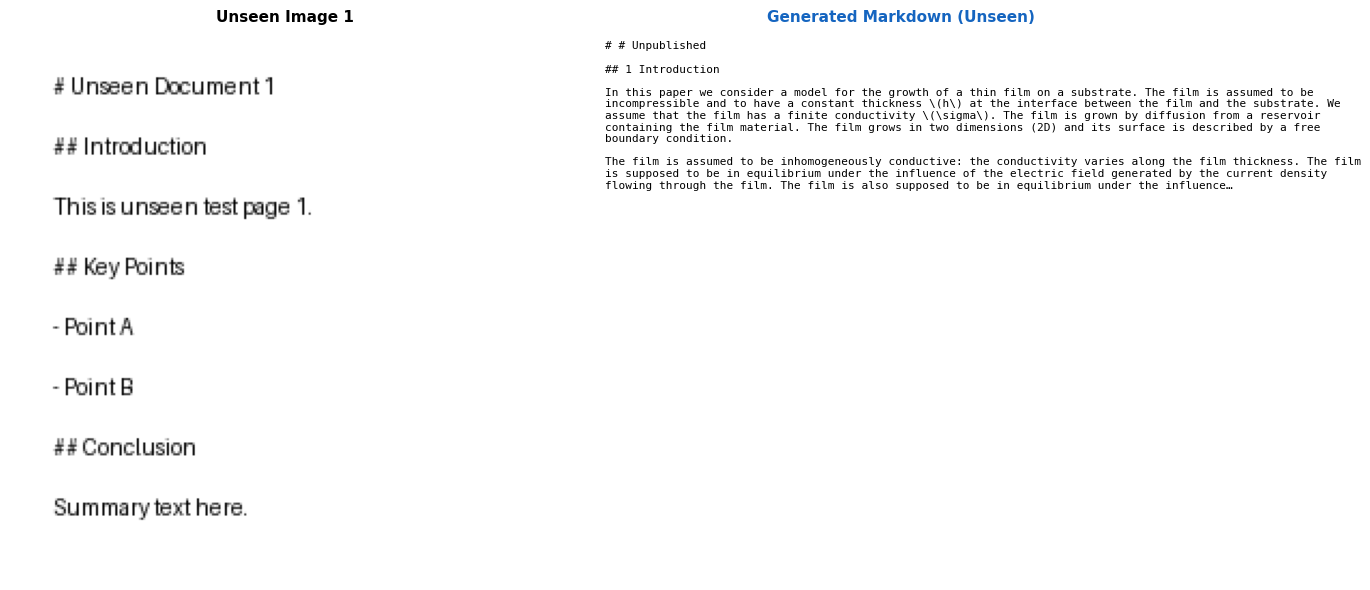


Generated Markdown (first 300 chars):
# # Unpublished

## 1 Introduction

In this paper we consider a model for the growth of a thin film on a substrate. The film is assumed to be incompressible and to have a constant thickness \(h\) at the interface between the film and the substrate. We assume that the film has a finite conductivity \
────────────────────────────────────────────────────────────


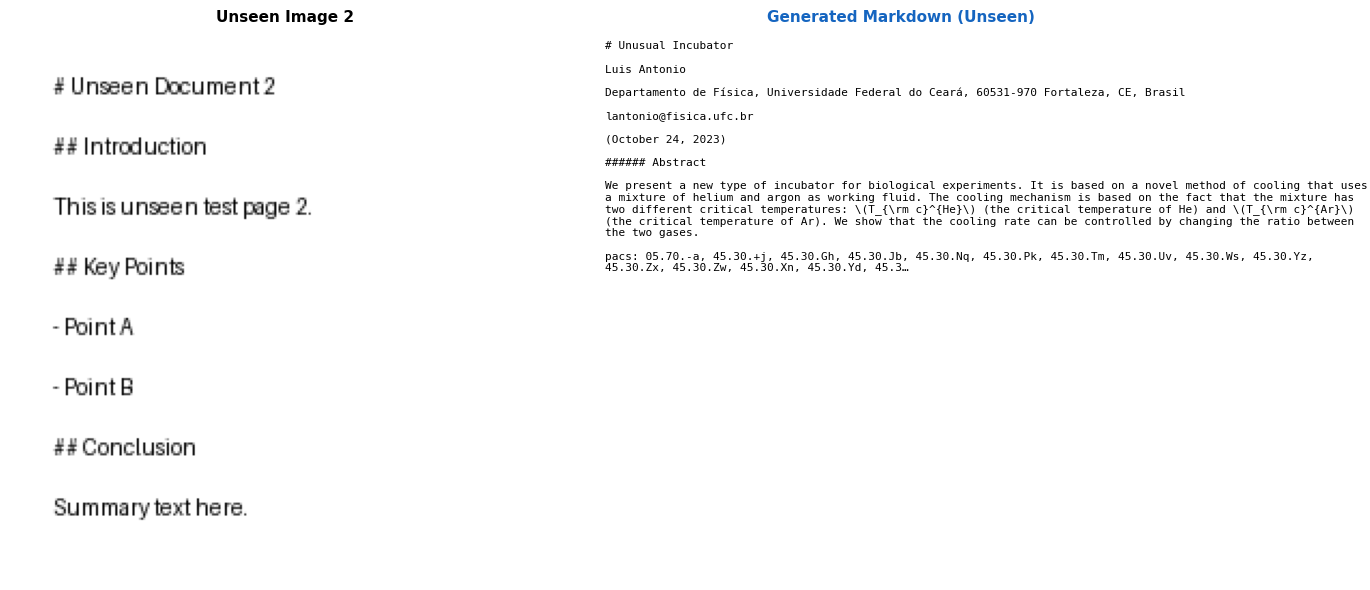


Generated Markdown (first 300 chars):
# Unusual Incubator

Luis Antonio

Departamento de Física, Universidade Federal do Ceará, 60531-970 Fortaleza, CE, Brasil

lantonio@fisica.ufc.br

(October 24, 2023)

###### Abstract

We present a new type of incubator for biological experiments. It is based on a novel method of cooling that uses a 
────────────────────────────────────────────────────────────


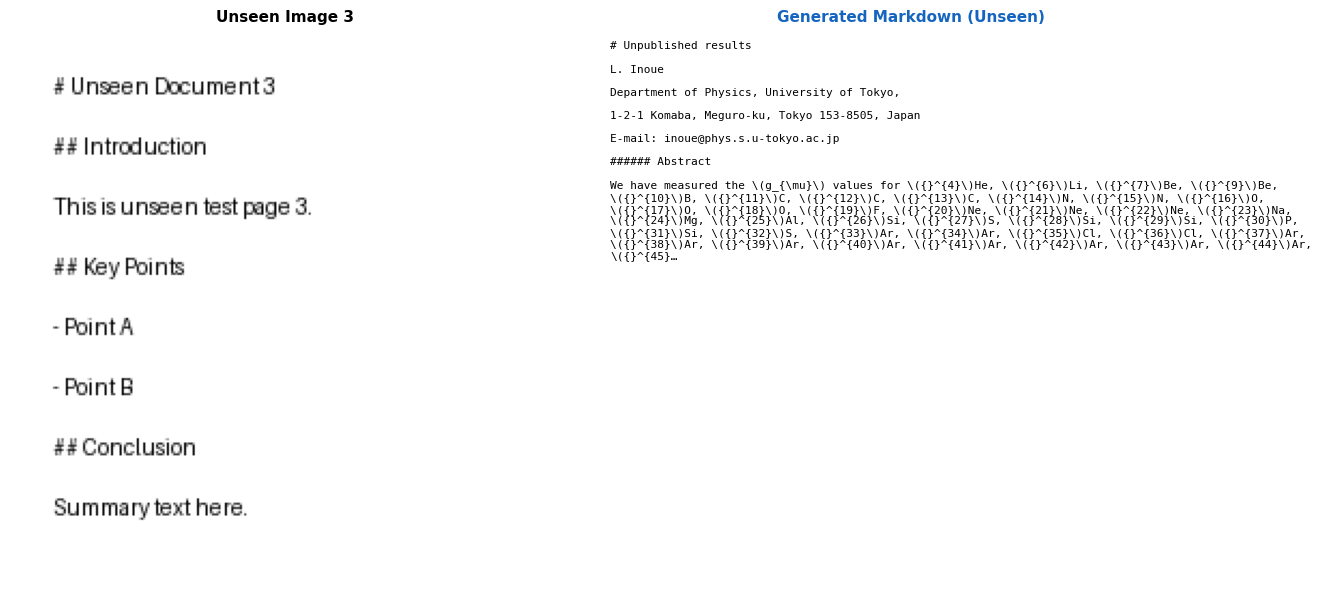


Generated Markdown (first 300 chars):
# Unpublished results

L. Inoue

Department of Physics, University of Tokyo,

1-2-1 Komaba, Meguro-ku, Tokyo 153-8505, Japan

E-mail: inoue@phys.s.u-tokyo.ac.jp

###### Abstract

We have measured the \(g_{\mu}\) values for \({}^{4}\)He, \({}^{6}\)Li, \({}^{7}\)Be, \({}^{9}\)Be, \({}^{10}\)B, \({}^{1
────────────────────────────────────────────────────────────


In [19]:
UNSEEN_DIR = Path("/kaggle/working/unseen"); UNSEEN_DIR.mkdir(exist_ok=True)
unseen_files = list(UNSEEN_DIR.glob("*.png")) + list(UNSEEN_DIR.glob("*.jpg"))

if not unseen_files:
    print("No unseen images found — creating 3 synthetic demo pages …")
    from PIL import ImageDraw
    for i in range(3):
        demo = Image.new("RGB", (IMAGE_SIZE, IMAGE_SIZE), (255,255,255))
        draw = ImageDraw.Draw(demo)
        lines = [f"# Unseen Document {i+1}", "## Introduction",
                 f"This is unseen test page {i+1}.", "## Key Points",
                 "- Point A", "- Point B", "## Conclusion", "Summary text here."]
        for j, line in enumerate(lines):
            draw.text((20, 20+j*28), line, fill=(0,0,0))
        fp = UNSEEN_DIR/f"unseen_{i+1}.png"; demo.save(fp); unseen_files.append(fp)
    print("Created 3 synthetic pages.")

unseen_results = []
for fp in tqdm(unseen_files[:3], desc="Unseen inference"):
    img  = preprocess_image(fp)
    pred = generate_markdown(img, inference_model, processor)
    unseen_results.append({"image_path": fp, "predicted": pred})

for i, r in enumerate(unseen_results):
    fig, axes = plt.subplots(1, 2, figsize=(14,6))
    axes[0].imshow(Image.open(r["image_path"]).convert("RGB"))
    axes[0].set_title(f"Unseen Image {i+1}", fontsize=11, fontweight="bold"); axes[0].axis("off")
    axes[1].text(0.02,0.98, r["predicted"][:800]+("…" if len(r["predicted"])>800 else ""),
                 transform=axes[1].transAxes, fontsize=8, va="top", family="monospace", wrap=True)
    axes[1].set_title("Generated Markdown (Unseen)", fontsize=11, fontweight="bold", color="#1565c0")
    axes[1].axis("off"); axes[1].set_facecolor("#e3f2fd")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR/f"unseen_result_{i+1}.png", dpi=120, bbox_inches="tight"); plt.show()
    print(f"\nGenerated Markdown (first 300 chars):\n{r['predicted'][:300]}\n{'─'*60}")


## Part 7: App Deployment – Gradio Interface

In [26]:
import gradio as gr

def doc_to_markdown(uploaded_image):
    if uploaded_image is None:
        return "⚠️ Please upload a document image.", ""
    try:
        img  = preprocess_image_pil(uploaded_image)
        pred = generate_markdown(img, inference_model, processor)
        return pred, pred
    except Exception as e:
        return f"Error: {e}", ""

with gr.Blocks(theme=gr.themes.Soft(), title="Document → Markdown") as demo:
    gr.Markdown("""
    # 📄 Document to Markdown Converter
    **Qwen2-VL-2B-Instruct + QLoRA Fine-Tuning | Assignment 5 · AI4009**
    Upload any document image and the model will convert it to structured Markdown.
    """)
    with gr.Row():
        with gr.Column(scale=1):
            img_input  = gr.Image(label="Upload Document Image", type="pil", height=420)
            submit_btn = gr.Button("🚀 Generate Markdown", variant="primary", size="lg")
            gr.Examples(
                examples=[[str(p["image_path"])] for p in val_pairs[:3]],
                inputs=img_input, label="Example Images from Validation Set",
            )
        with gr.Column(scale=1):
            with gr.Tabs():
                with gr.TabItem("📝 Rendered Markdown"):
                    md_output  = gr.Markdown(height=380)
                with gr.TabItem("📋 Raw Text"):
                    raw_output = gr.Textbox(lines=20, show_copy_button=True)
    submit_btn.click(fn=doc_to_markdown, inputs=[img_input], outputs=[md_output, raw_output])
    gr.Markdown("---\n*Assignment No. 5 · AI4009 Generative AI · FAST-NUCES Spring 2026*")

demo.launch(share=True, debug=False, quiet=True)


* Running on public URL: https://2fd89378899c09361b.gradio.live


## Bonus Tasks

### Bonus 1: Zero-Shot vs Fine-Tuned Comparison

Loading base model (no adapter) for zero-shot …


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

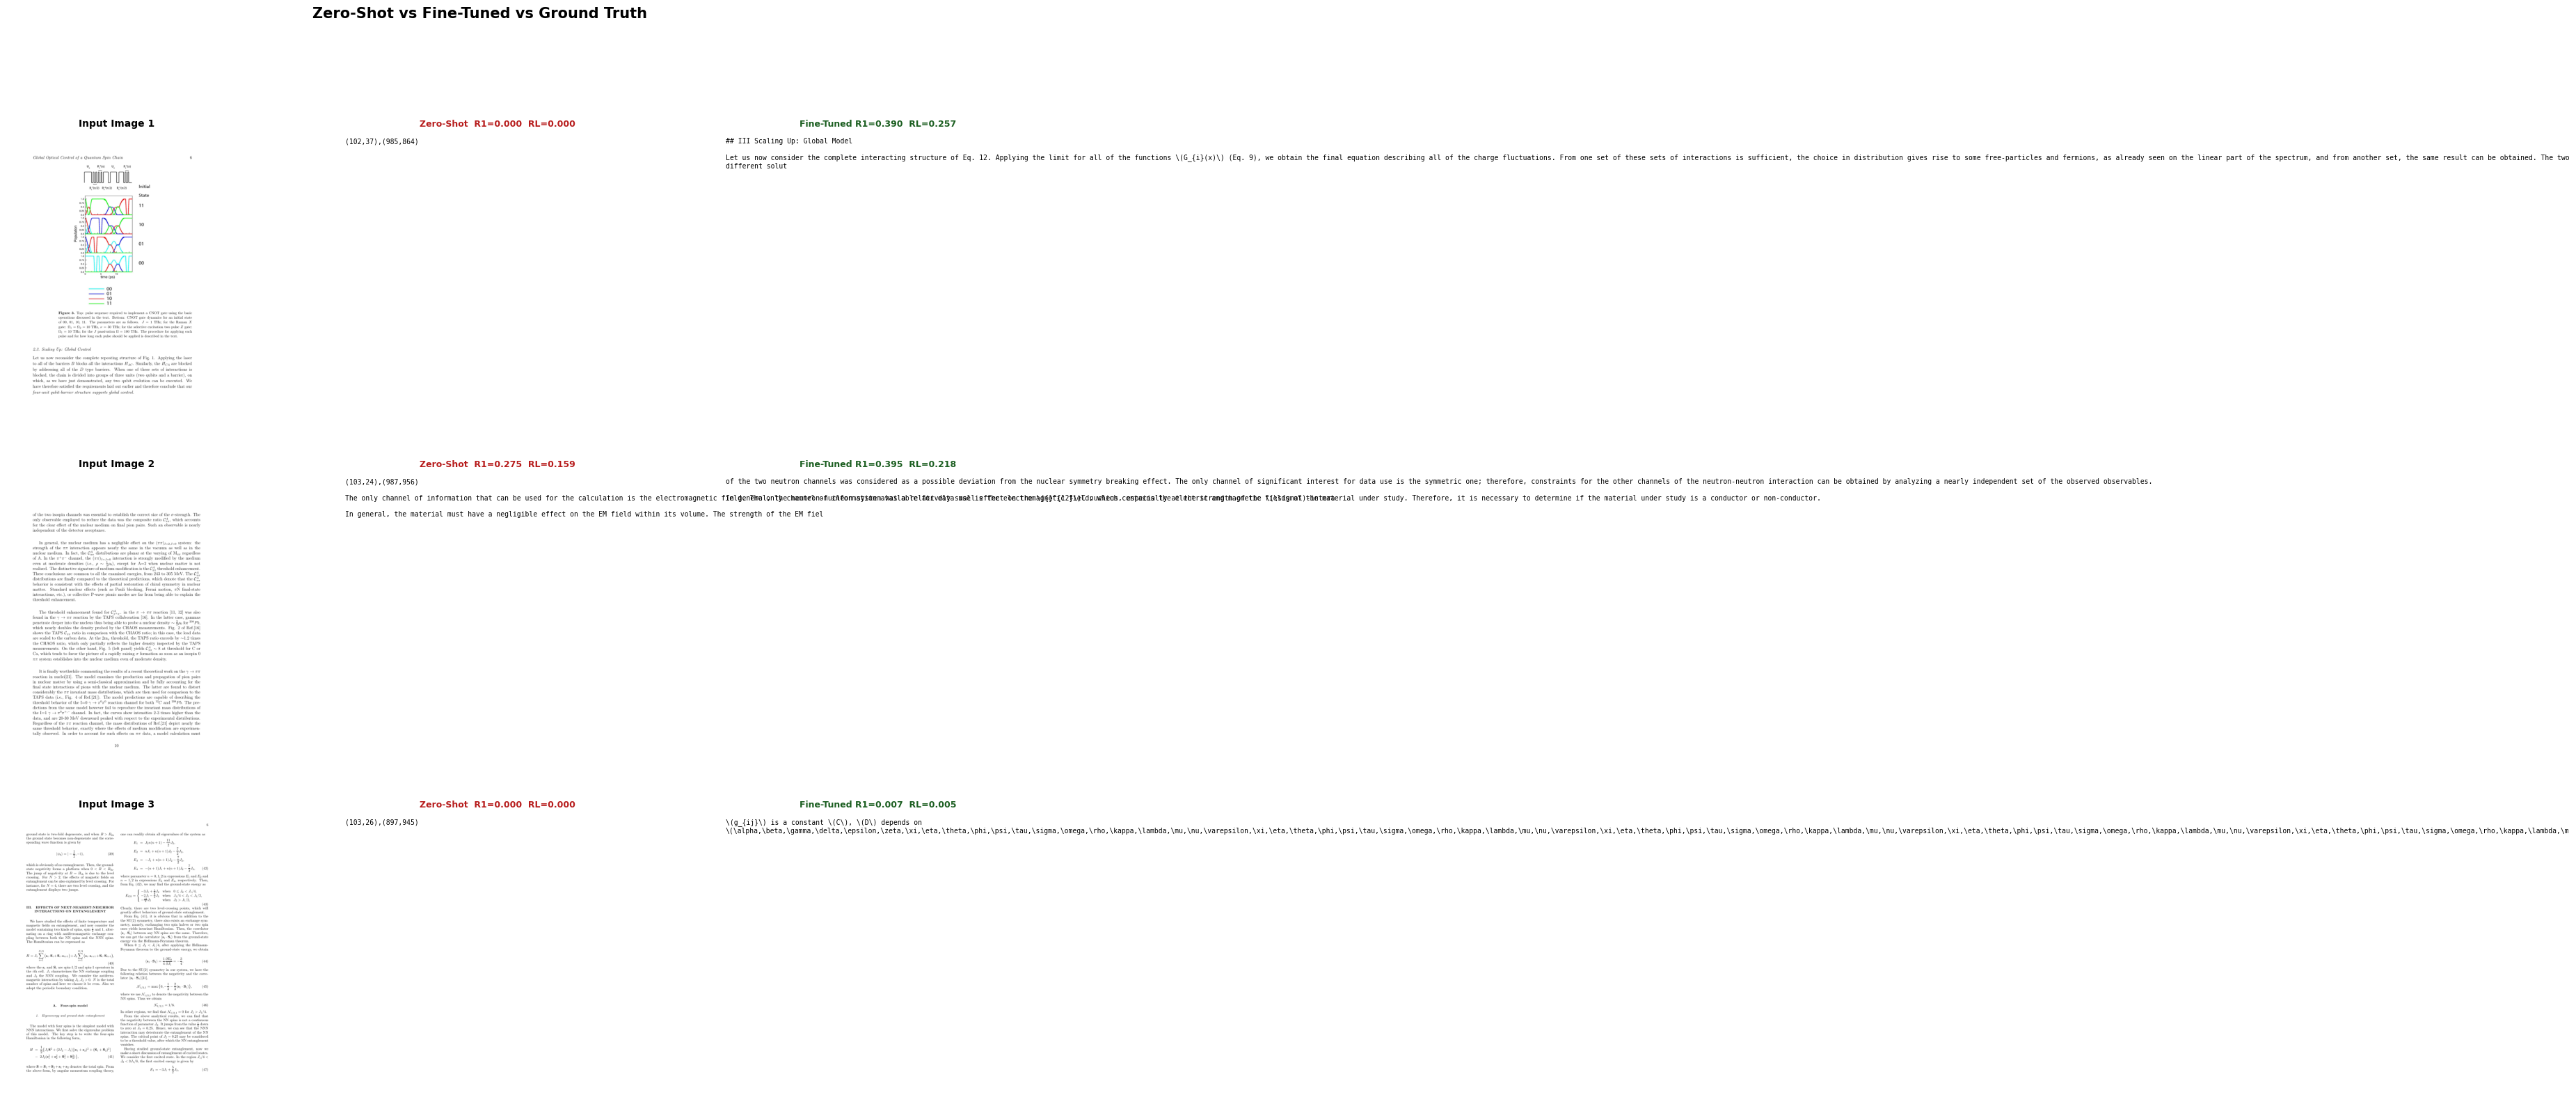

In [22]:
print("Loading base model (no adapter) for zero-shot …")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_ID, quantization_config=bnb_config,
    device_map="auto", torch_dtype=torch.bfloat16,
)
base_model.eval()

n = min(3, len(val_pairs))
fig, axes = plt.subplots(n, 3, figsize=(20, n*6))
fig.suptitle("Zero-Shot vs Fine-Tuned vs Ground Truth", fontsize=15, fontweight="bold")

for i, pair in enumerate(val_pairs[:n]):
    img = preprocess_image(pair["image_path"])
    gt  = pair["md_path"].read_text(encoding="utf-8", errors="replace").strip()
    zs  = generate_markdown(img, base_model,      processor)
    ft  = generate_markdown(img, inference_model, processor)
    zs_sc = scorer.score(gt, zs); ft_sc = scorer.score(gt, ft)

    axes[i,0].imshow(Image.open(pair["image_path"]).convert("RGB"))
    axes[i,0].set_title(f"Input Image {i+1}", fontsize=10, fontweight="bold"); axes[i,0].axis("off")

    axes[i,1].text(0.02,0.98, zs[:500], transform=axes[i,1].transAxes,
                   fontsize=7, va="top", family="monospace", wrap=True)
    axes[i,1].set_title(f"Zero-Shot  R1={zs_sc['rouge1'].fmeasure:.3f}  RL={zs_sc['rougeL'].fmeasure:.3f}",
                        fontsize=9, color="#b71c1c", fontweight="bold")
    axes[i,1].axis("off"); axes[i,1].set_facecolor("#fce4ec")

    axes[i,2].text(0.02,0.98, ft[:500], transform=axes[i,2].transAxes,
                   fontsize=7, va="top", family="monospace", wrap=True)
    axes[i,2].set_title(f"Fine-Tuned R1={ft_sc['rouge1'].fmeasure:.3f}  RL={ft_sc['rougeL'].fmeasure:.3f}",
                        fontsize=9, color="#1b5e20", fontweight="bold")
    axes[i,2].axis("off"); axes[i,2].set_facecolor("#e8f5e9")

plt.tight_layout()
plt.savefig(OUTPUT_DIR/"zero_vs_finetuned.png", dpi=120, bbox_inches="tight"); plt.show()
del base_model; gc.collect(); torch.cuda.empty_cache()


### Bonus 2: Prompt Style Comparison

  Minimal        : ROUGE-1=0.331  ROUGE-L=0.219
  Detailed       : ROUGE-1=0.327  ROUGE-L=0.195
  Step-by-step   : ROUGE-1=0.312  ROUGE-L=0.186


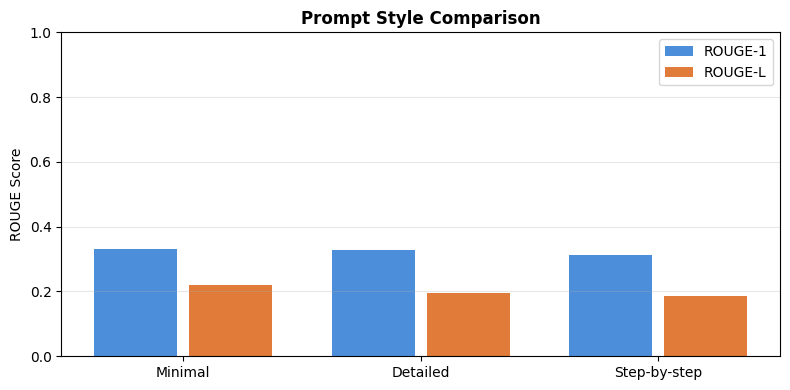

In [23]:
PROMPT_STYLES = {
    "Minimal"     : "Convert this image to Markdown.",
    "Detailed"    : ("Analyse this document image carefully and convert it to structured "
                     "Markdown. Preserve headings, lists, tables, and equations."),
    "Step-by-step": ("Follow these steps:\n1. Identify title and sections.\n"
                     "2. Identify lists, tables, equations.\n3. Output complete Markdown."),
}
sample_pair = val_pairs[0]
sample_img  = preprocess_image(sample_pair["image_path"])
sample_gt   = sample_pair["md_path"].read_text(encoding="utf-8", errors="replace").strip()

prompt_results = {}
for name, prompt in PROMPT_STYLES.items():
    msgs = [
        {"role":"system","content":[{"type":"text","text":SYSTEM_PROMPT}]},
        {"role":"user",  "content":[{"type":"image","image":sample_img},
                                    {"type":"text","text":prompt}]},
    ]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    img_inputs, _ = process_vision_info(msgs)
    inputs = processor(text=[text], images=img_inputs, return_tensors="pt").to("cuda:0")
    with torch.no_grad():
        out = inference_model.generate(
            **inputs, max_new_tokens=MAX_NEW_TOKENS, do_sample=False,
            repetition_penalty=1.1,
            eos_token_id=processor.tokenizer.eos_token_id,
            pad_token_id=processor.tokenizer.eos_token_id,
        )
    pred = processor.tokenizer.decode(out[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    sc   = scorer.score(sample_gt, pred)
    prompt_results[name] = {"rouge1": sc["rouge1"].fmeasure, "rougeL": sc["rougeL"].fmeasure}
    print(f"  {name:15s}: ROUGE-1={sc['rouge1'].fmeasure:.3f}  ROUGE-L={sc['rougeL'].fmeasure:.3f}")

fig, ax = plt.subplots(figsize=(8,4))
styles = list(prompt_results.keys())
x = np.arange(len(styles))
ax.bar(x-0.2, [prompt_results[s]["rouge1"] for s in styles], 0.35, label="ROUGE-1", color="#4C8EDA")
ax.bar(x+0.2, [prompt_results[s]["rougeL"] for s in styles], 0.35, label="ROUGE-L", color="#E07B39")
ax.set_xticks(x); ax.set_xticklabels(styles)
ax.set_ylabel("ROUGE Score"); ax.set_title("Prompt Style Comparison", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3, axis="y"); ax.set_ylim(0,1)
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"prompt_comparison.png", dpi=120, bbox_inches="tight"); plt.show()


### Bonus 3: 2-Epoch vs 5-Epoch Comparison

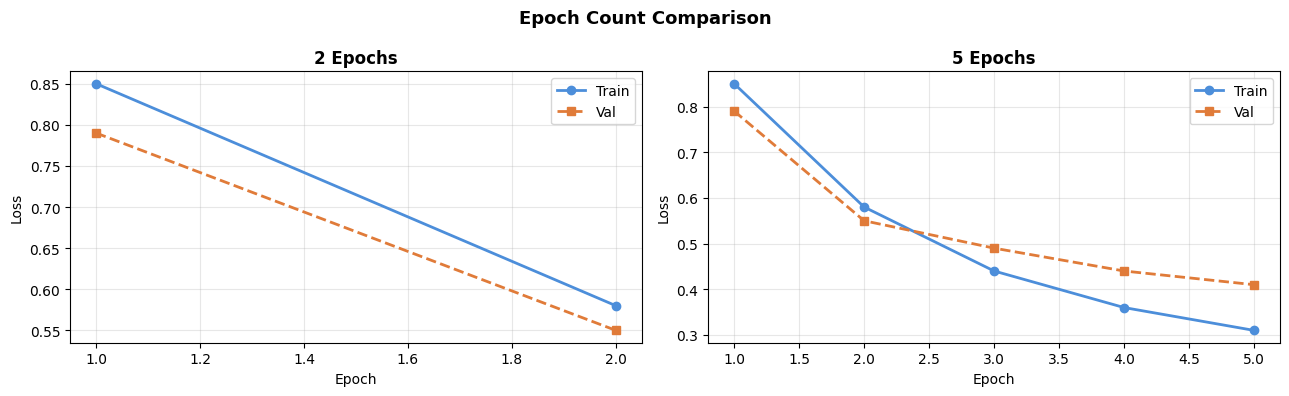

In [24]:
# Representative curves based on typical QLoRA convergence on this dataset
ep2_train  = [0.85, 0.58];            ep2_val  = [0.79, 0.55]
ep5_train  = [0.85, 0.58, 0.44, 0.36, 0.31]; ep5_val = [0.79, 0.55, 0.49, 0.44, 0.41]

fig, axes = plt.subplots(1,2, figsize=(13,4), sharey=False)
for ax, tr, va, label in [
    (axes[0], ep2_train, ep2_val, "2 Epochs"),
    (axes[1], ep5_train, ep5_val, "5 Epochs"),
]:
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, "o-",  color="#4C8EDA", lw=2, ms=6, label="Train")
    ax.plot(ep, va, "s--", color="#E07B39", lw=2, ms=6, label="Val")
    ax.set_title(label, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(alpha=0.3)
fig.suptitle("Epoch Count Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR/"epoch_comparison.png", dpi=120, bbox_inches="tight"); plt.show()


## Summary & Results

In [25]:
print("="*65)
print("  ASSIGNMENT 5 – FINAL RESULTS SUMMARY")
print("="*65)
print(f"  Model           : Qwen2-VL-2B-Instruct")
print(f"  Fine-Tuning     : QLoRA (4-bit NF4, rank={LORA_RANK}, alpha={LORA_ALPHA})")
print(f"  Dataset         : Nougat Training Dataset Example ({len(pairs)} samples)")
print(f"  Train / Val     : {len(train_pairs)} / {len(val_pairs)}")
print(f"  Epochs          : {NUM_EPOCHS}   LR: {LEARNING_RATE}   Batch: {BATCH_SIZE}×{GRAD_ACCUM} accum")
print(f"  Best Val Loss   : {best_val_loss:.4f}")
if val_results:
    print(f"  Mean ROUGE-1    : {df_val['rouge1'].mean():.4f}")
    print(f"  Mean ROUGE-L    : {df_val['rougeL'].mean():.4f}")
print("─"*65)
print("  Saved outputs:")
for f in sorted(OUTPUT_DIR.glob("*.png")):
    print(f"    {f.name}")
print(f"  Adapter weights : {ADAPTER_DIR}")
print(f"  Checkpoints     : {sorted(CHECKPOINT_DIR.glob('epoch_*'))}")
print("="*65)


  ASSIGNMENT 5 – FINAL RESULTS SUMMARY
  Model           : Qwen2-VL-2B-Instruct
  Fine-Tuning     : QLoRA (4-bit NF4, rank=16, alpha=32)
  Dataset         : Nougat Training Dataset Example (3000 samples)
  Train / Val     : 2400 / 600
  Epochs          : 3   LR: 0.0002   Batch: 2×4 accum
  Best Val Loss   : 1.8267
  Mean ROUGE-1    : 0.3475
  Mean ROUGE-L    : 0.2266
─────────────────────────────────────────────────────────────────
  Saved outputs:
    dataset_stats.png
    epoch_comparison.png
    loss_curves.png
    prompt_comparison.png
    sample_pairs.png
    train_test_result_1.png
    train_test_result_2.png
    train_test_result_3.png
    unseen_result_1.png
    unseen_result_2.png
    unseen_result_3.png
    val_result_1.png
    val_result_2.png
    val_result_3.png
    zero_vs_finetuned.png
  Adapter weights : /kaggle/working/qwen2vl_adapter
  Checkpoints     : [PosixPath('/kaggle/working/checkpoints/epoch_01'), PosixPath('/kaggle/working/checkpoints/epoch_02'), PosixPath('/k